<a href="https://colab.research.google.com/github/Victorpc132/ProjetosPythonRauber/blob/main/02_Projeto_Iris_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌸 Projeto de Machine Learning – Dataset Iris

Este notebook segue as **Etapas do Projeto de ML** definidas.

## 1. Definição do Problema
Nosso objetivo será **classificar flores da base Iris** em três espécies: *setosa*, *versicolor* e *virginica*.

Trabalharemos com dados numéricos.

- **Variável alvo (target):** espécie da flor.
- **Métricas de sucesso:** *accuracy* (acurácia) será a métrica principal, mas também veremos *precision*, *recall* e *F1-score*.  

Como dito anteriormente, trabalharemos com dados numéricos que representam as medidas (em centímetros) das partes das flores. Veja:


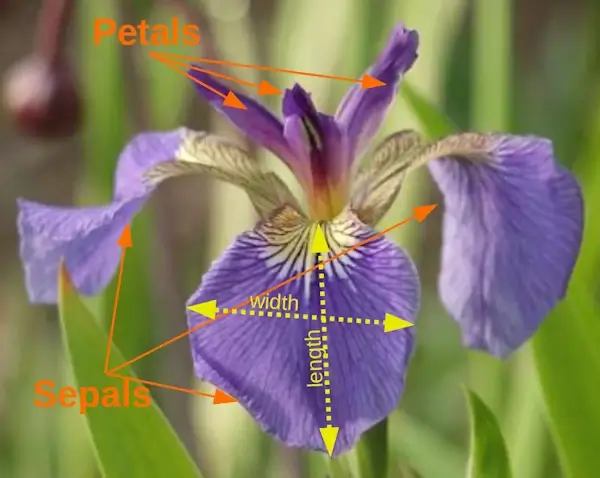


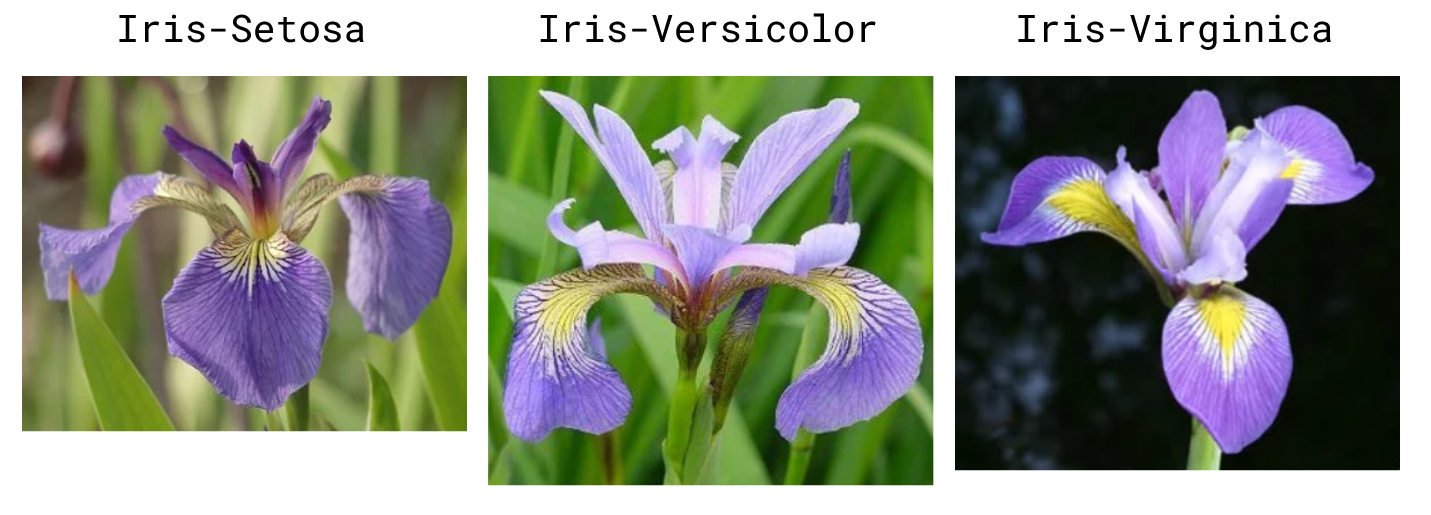


In [9]:
# Importações iniciais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

## 2. Coletar Dados
Aqui usamos o dataset **Iris** já disponível no `scikit-learn`.  

In [10]:
# Carregando dataset Iris
iris = datasets.load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

# Classes do target
species_names = iris.target_names
print("Espécies:", species_names)
X.head()

Espécies: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 3. Explorar Dados
Vamos entender as distribuições e relações entre variáveis.

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


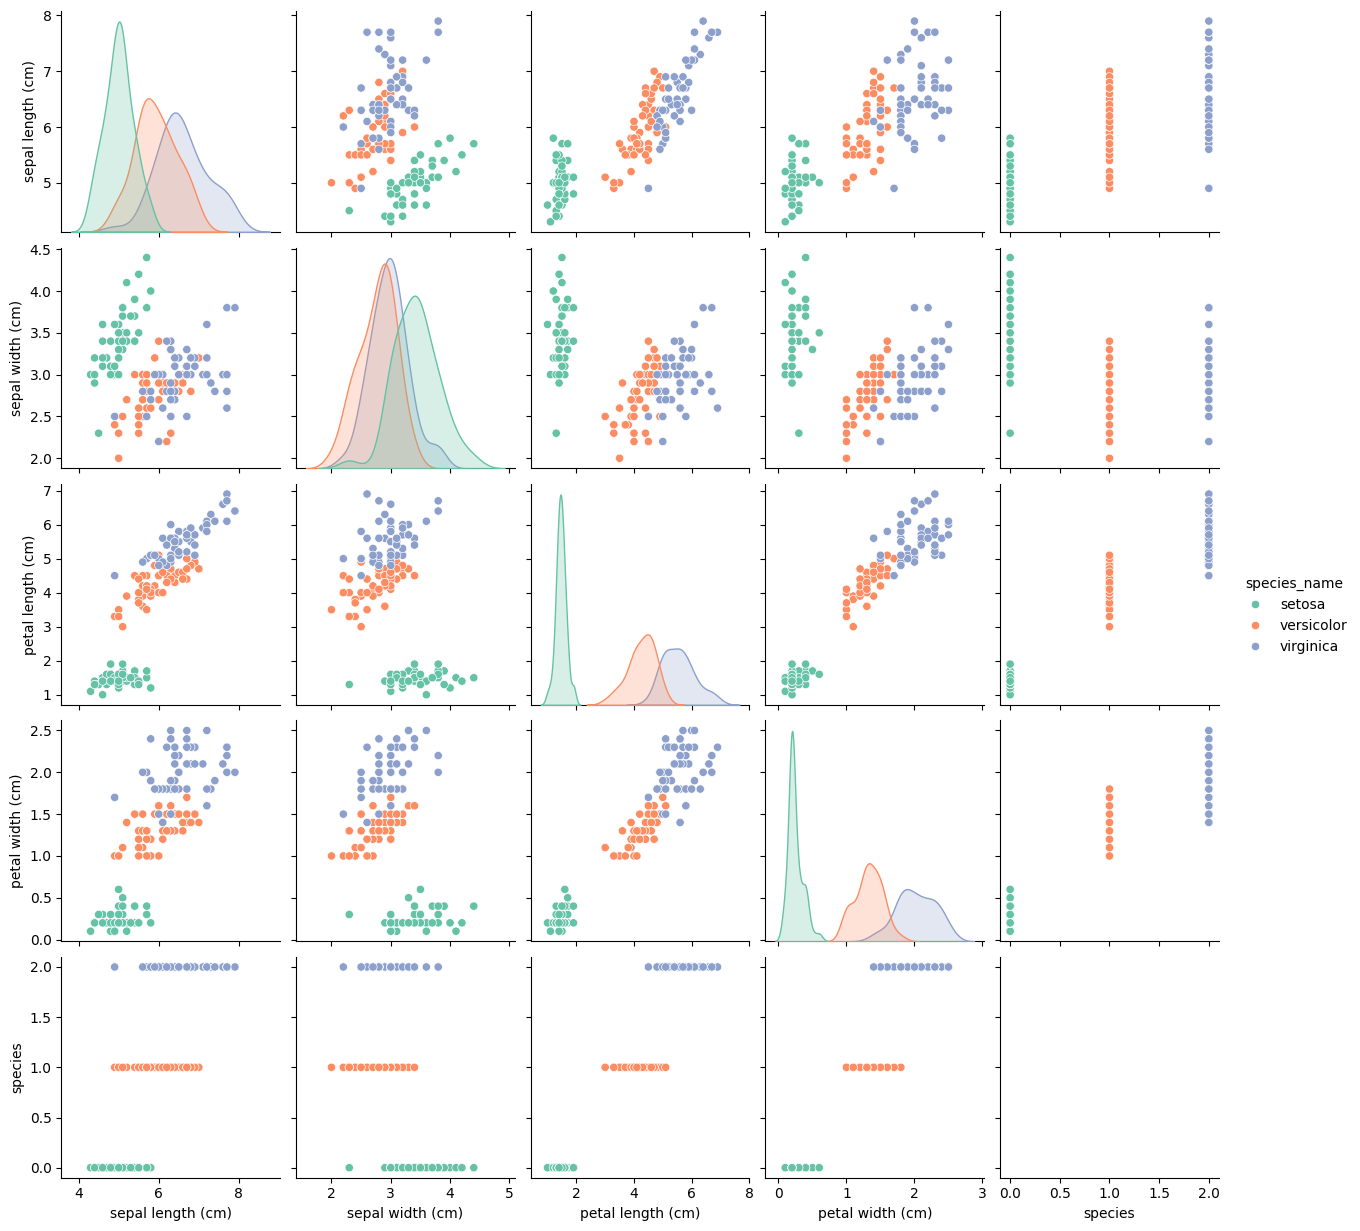

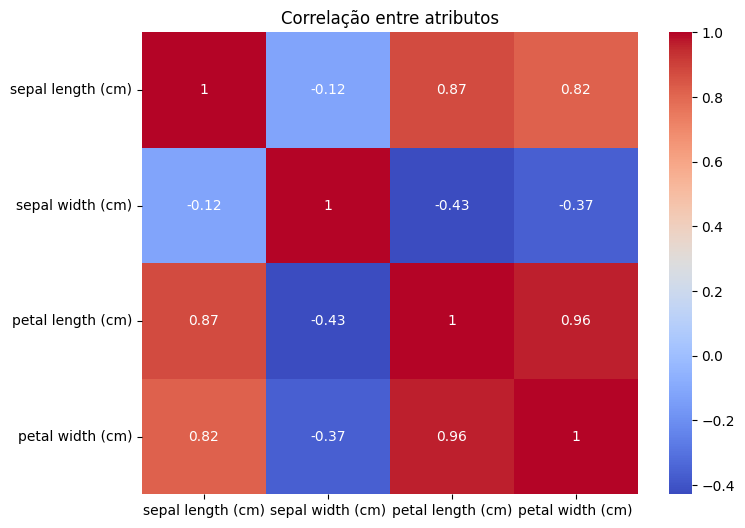

In [11]:
# Estatísticas descritivas
print(X.describe())

# Visualização das distribuições
# Mapear os números das espécies para seus nomes para o pairplot
df_viz = pd.concat([X, y], axis=1)
df_viz['species_name'] = df_viz['species'].map(lambda x: species_names[x])

sns.pairplot(df_viz, hue="species_name", palette="Set2")
plt.show()

# Correlações
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Correlação entre atributos")
plt.show()

## 4. Preparar Dados
- O dataset Iris não possui valores ausentes.
- Vamos apenas **padronizar os atributos numéricos** para que algoritmos sensíveis à escala (como SVM) funcionem bem.

In [12]:
# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## 5. Identificar Modelos Promissores


5.1 Testaremos aqui um **SVM (Support Vector Machine)**, que é eficiente em problemas de classificação.  Usaremos pipeline para garantir que o pré-processamento esteja acoplado ao modelo.

In [ ]:
# Pipeline: Padronização + SVM
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC())
])

# Definição de hiperparâmetros candidatos
param_grid = {
    "svc__C": [0.1, 1, 10],
    "svc__kernel": ["linear", "rbf"],
    "svc__gamma": ["scale", "auto"]
}

# GridSearch com validação cruzada
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)
print("Melhor acurácia de validação:", grid.best_score_)

5.2 Testaremos aqui um **RF (random forest)**, é um metaestimador que ajusta vários regressores de árvore de decisão em várias subamostras do conjunto de dados e usa a média para melhorar a precisão preditiva e controlar o sobreajuste.  Usaremos pipeline para garantir que o pré-processamento esteja acoplado ao modelo.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Pipeline: Padronização + RandomForestClassifier
pipeline_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(random_state=42)) # Adicionado random_state para reprodutibilidade
])

# Definição de hiperparâmetros candidatos para RandomForest
param_grid_rf = {
    "rf__n_estimators": [50, 100, 200],
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_split": [2, 5, 10]
}

# GridSearch com validação cruzada para RandomForest
grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring="accuracy")
grid_rf.fit(X_train, y_train)

print("\n--- Resultados para RandomForest ---")
print("Melhores parâmetros:", grid_rf.best_params_)
print("Melhor acurácia de validação:", grid_rf.best_score_)


## 6. Aperfeiçoar o Modelo
Agora avaliamos o modelo no conjunto de **teste**.

In [ ]:
# Previsões
y_pred = grid.predict(X_test)

# Relatório de métricas
print(classification_report(y_test, y_pred, target_names=species_names))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=species_names, yticklabels=species_names)
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

## 7. Implantar
No contexto educacional/Google Colab, a implantação pode ser apenas salvar o modelo treinado.

In [ ]:
import joblib

# Salvando modelo final
joblib.dump(grid.best_estimator_, "modelo_iris.pkl")
print("Modelo salvo como modelo_iris.pkl")

## 8. Monitorar e Manter
Em projetos reais, monitoraríamos métricas em produção.  
Aqui, apenas deixamos registrado que o modelo deve ser reavaliado periodicamente com novos dados de flores.

#📑 Atividade de aprendizagem

1. Avalie o modelo RF (random forest) com dados do conjunto de testes.

2. Qual dos dois modelos se saiu melhor com dados do conjunto de testes?